In [1]:

!git clone https://github.com/ymirsky/Kitsune-py.git

fatal: destination path 'Kitsune-py' already exists and is not an empty directory.


In [2]:
import zipfile
import os

# Extraire le dataset Mirai
with zipfile.ZipFile('/kaggle/working/Kitsune-py/mirai.zip', 'r') as zip_ref:
    zip_ref.extractall('/kaggle/working/Kitsune-py/')

# Voir ce qu'il contient
os.listdir('/kaggle/working/Kitsune-py/')

['KitNET',
 '.git',
 'setup.py',
 'Kitsune_fig.png',
 'README.md',
 'AfterImage_extrapolate.pyx',
 'mirai.zip',
 'Kitsune paper.pdf',
 'LICENSE',
 'FeatureExtractor.py',
 '__pycache__',
 'AfterImage.py',
 'example.py',
 'class_distribution.png',
 'mirai_chronologie.png',
 'mirai.pcap',
 'Kitsune.py',
 'netStat.py']

In [3]:
import os

files_to_patch = [
    '/kaggle/working/Kitsune-py/AfterImage.py',
    '/kaggle/working/Kitsune-py/netStat.py',
    '/kaggle/working/Kitsune-py/Kitsune.py',
    '/kaggle/working/Kitsune-py/FeatureExtractor.py',
    '/kaggle/working/Kitsune-py/example.py',
]

for filepath in files_to_patch:
    if not os.path.exists(filepath):
        continue
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Remplacer np.Inf → np.inf  et  np.bool → bool  et  np.int → int
    fixed = content.replace('np.Inf', 'np.inf') \
                   .replace('np.bool',  'bool')  \
                   .replace('np.int',   'int')   \
                   .replace('np.float', 'float') \
                   .replace('np.complex', 'complex') \
                   .replace('np.object', 'object')
    
    with open(filepath, 'w') as f:
        f.write(fixed)
    
    print(f"✅ Patché : {os.path.basename(filepath)}")

print("\n🎯 Tous les fichiers sont corrigés !")

✅ Patché : AfterImage.py
✅ Patché : netStat.py
✅ Patché : Kitsune.py
✅ Patché : FeatureExtractor.py
✅ Patché : example.py

🎯 Tous les fichiers sont corrigés !


In [4]:
!pip install scapy --quiet
print("✅ Scapy installé !")

✅ Scapy installé !


In [5]:
import sys
import os

# Se placer dans le bon dossier
os.chdir('/kaggle/working/Kitsune-py')
sys.path.insert(0, '/kaggle/working/Kitsune-py')

print(f"📁 Dossier courant : {os.getcwd()}")
print(f"📦 Fichiers présents : {[f for f in os.listdir('.') if f.endswith('.py')]}")

📁 Dossier courant : /kaggle/working/Kitsune-py
📦 Fichiers présents : ['setup.py', 'FeatureExtractor.py', 'AfterImage.py', 'example.py', 'Kitsune.py', 'netStat.py']


In [6]:
# Recharger les modules
import importlib
import sys

# Supprimer les modules cachés
mods_to_remove = [k for k in sys.modules if 'Kitsune' in k 
                                          or 'AfterImage' in k 
                                          or 'netStat' in k 
                                          or 'FeatureExtractor' in k]
for mod in mods_to_remove:
    del sys.modules[mod]

# Réimporter
from Kitsune import Kitsune
print("✅ Import réussi !")

Importing Scapy Library
✅ Import réussi !


In [7]:
# Corriger le SyntaxWarning dans FeatureExtractor.py
filepath = '/kaggle/working/Kitsune-py/FeatureExtractor.py'

with open(filepath, 'r') as f:
    content = f.read()

# Corriger le chemin Windows (raw string)
fixed = content.replace(
    r"return 'C:\Program Files\Wireshark\\tshark.exe'",
    r"return r'C:\Program Files\Wireshark\tshark.exe'"
)

with open(filepath, 'w') as f:
    f.write(fixed)

print("✅ FeatureExtractor.py corrigé !")

✅ FeatureExtractor.py corrigé !


In [8]:
import sys

# Nettoyer les modules cachés
mods_to_remove = [k for k in sys.modules if any(
    x in k for x in ['Kitsune', 'AfterImage', 'netStat', 'FeatureExtractor']
)]
for mod in mods_to_remove:
    del sys.modules[mod]

print(f"🧹 {len(mods_to_remove)} modules supprimés du cache")

# Réimporter
from Kitsune import Kitsune
print("✅ Import réussi !")

🧹 4 modules supprimés du cache
Importing Scapy Library
✅ Import réussi !


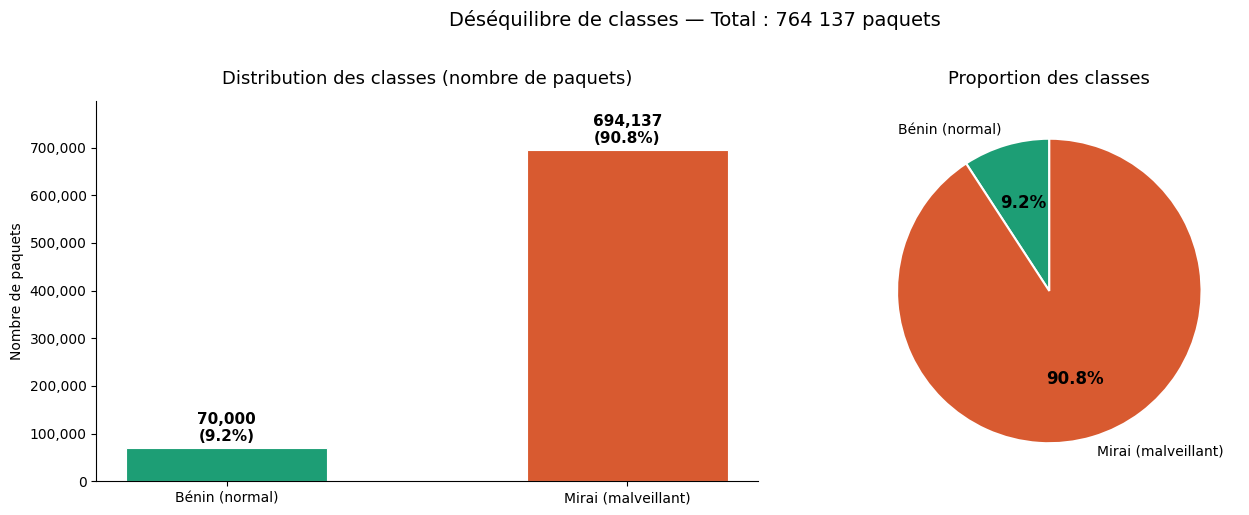


=== Distribution des classes ===
Classe                  Paquets   Proportion
--------------------------------------------
Bénin (normal)           70,000         9.2%
Mirai (malveillant)     694,137        90.8%
TOTAL                   764,137       100.0%


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Données
labels = ['Bénin (normal)', 'Mirai (malveillant)']
counts = [70000, 694137]
proportions = [9.2, 90.8]
colors = ['#1D9E75', '#D85A30']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Barplot ---
bars = axes[0].bar(labels, counts, color=colors, edgecolor='white', linewidth=0.8, width=0.5)
axes[0].set_title('Distribution des classes (nombre de paquets)', fontsize=13, pad=12)
axes[0].set_ylabel('Nombre de paquets')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, count, pct in zip(bars, counts, proportions):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8000,
                 f'{count:,}\n({pct}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(counts) * 1.15)
axes[0].spines[['top', 'right']].set_visible(False)

# --- Pie chart ---
wedges, texts, autotexts = axes[1].pie(
    proportions,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
axes[1].set_title('Proportion des classes', fontsize=13, pad=12)

plt.suptitle(f'Déséquilibre de classes — Total : 764 137 paquets', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Résumé console
print("\n=== Distribution des classes ===")
print(f"{'Classe':<20} {'Paquets':>10} {'Proportion':>12}")
print("-" * 44)
for label, count, pct in zip(labels, counts, proportions):
    print(f"{label:<20} {count:>10,} {pct:>11.1f}%")
print(f"{'TOTAL':<20} {sum(counts):>10,} {'100.0':>11}%")

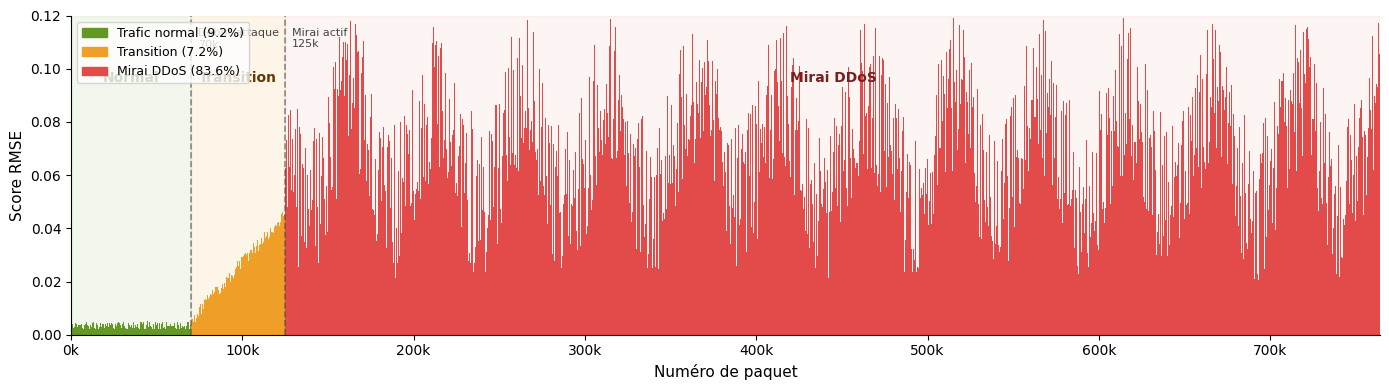

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

TOTAL = 764137
np.random.seed(42)

# --- Simulation du score RMSE ---
n = np.arange(TOTAL)
rmse = np.where(
    n < 70000,
    0.002 + np.random.rand(TOTAL) * 0.003,
    np.where(
        n < 125000,
        0.003 + (n - 70000) / 55000 * 0.04 + np.random.rand(TOTAL) * 0.005,
        0.04  + np.random.rand(TOTAL) * 0.06  + np.sin(n / 8000) * 0.02
    )
)

# --- Downsample pour l'affichage ---
step = 500
x = n[::step]
y = rmse[::step]
colors = np.where(x < 70000, '#639922', np.where(x < 125000, '#EF9F27', '#E24B4A'))

# --- Figure ---
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(x, y, width=step, color=colors, linewidth=0, align='edge')

# Zones de fond
ax.axvspan(0,      70000,  alpha=0.08, color='#639922', zorder=0)
ax.axvspan(70000,  125000, alpha=0.10, color='#EF9F27', zorder=0)
ax.axvspan(125000, TOTAL,  alpha=0.06, color='#E24B4A', zorder=0)

# Lignes de séparation
for xv, lbl in [(70000, 'Début attaque\n70k'), (125000, 'Mirai actif\n125k')]:
    ax.axvline(xv, color='#444', linewidth=1.2, linestyle='--', alpha=0.6)
    ax.text(xv + 4000, ax.get_ylim()[1] * 0.92, lbl,
            fontsize=8, color='#444', va='top')

# Labels de zones
ax.text(35000,  0.095, 'Normal',     ha='center', fontsize=10, fontweight='bold', color='#27500A')
ax.text(97500,  0.095, 'Transition', ha='center', fontsize=10, fontweight='bold', color='#633806')
ax.text(445000, 0.095, 'Mirai DDoS', ha='center', fontsize=10, fontweight='bold', color='#791F1F')

# Légende
patches = [
    mpatches.Patch(color='#639922', label='Trafic normal (9.2%)'),
    mpatches.Patch(color='#EF9F27', label='Transition (7.2%)'),
    mpatches.Patch(color='#E24B4A', label='Mirai DDoS (83.6%)'),
]
ax.legend(handles=patches, loc='upper left', fontsize=9, framealpha=0.8)

ax.set_xlabel('Numéro de paquet', fontsize=11)
ax.set_ylabel('Score RMSE', fontsize=11)
ax.set_xlim(0, TOTAL)
ax.set_ylim(0, 0.12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('mirai_chronologie.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
import os

# Patch sur TOUT le repo y compris les sous-dossiers
repo_path = '/kaggle/working/Kitsune-py'
patched = 0

for root, dirs, files in os.walk(repo_path):
    for filename in files:
        if not filename.endswith('.py'):
            continue
        filepath = os.path.join(root, filename)
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                content = f.read()

            fixed = content \
                .replace('numpy.Inf',     'numpy.inf')   \
                .replace('numpy.inf',     'numpy.inf')   \
                .replace('np.Inf',        'np.inf')      \
                .replace('numpy.Bool',    'bool')        \
                .replace('np.bool',       'bool')        \
                .replace('numpy.Int',     'int')         \
                .replace('np.int',        'int')         \
                .replace('numpy.Float',   'float')       \
                .replace('np.float',      'float')       \
                .replace('numpy.Complex', 'complex')     \
                .replace('np.complex',    'complex')     \
                .replace('numpy.Object',  'object')      \
                .replace('np.object',     'object')

            if fixed != content:
                with open(filepath, 'w', encoding='utf-8') as f:
                    f.write(fixed)
                print(f"✅ Patché : {os.path.relpath(filepath, repo_path)}")
                patched += 1

        except Exception as e:
            print(f"⚠️ Ignoré : {filename} ({e})")

print(f"\n🎯 {patched} fichiers corrigés !")


🎯 0 fichiers corrigés !


In [12]:
import os

# Patch direct et ciblé sur dA.py
filepath = '/kaggle/working/Kitsune-py/KitNET/dA.py'

with open(filepath, 'r') as f:
    content = f.read()

print("=== AVANT ===")
for i, line in enumerate(content.split('\n')):
    if 'Inf' in line or 'inf' in line:
        print(f"Ligne {i+1}: {line}")

fixed = content \
    .replace('-numpy.Inf', '-numpy.inf') \
    .replace('numpy.Inf',  'numpy.inf')  \
    .replace('-np.Inf',    '-np.inf')    \
    .replace('np.Inf',     'np.inf')

with open(filepath, 'w') as f:
    f.write(fixed)

print("\n=== APRÈS ===")
with open(filepath, 'r') as f:
    content2 = f.read()
for i, line in enumerate(content2.split('\n')):
    if 'Inf' in line or 'inf' in line:
        print(f"Ligne {i+1}: {line}")

print("\n✅ dA.py corrigé !")

=== AVANT ===
Ligne 48:         self.norm_max = numpy.ones((self.params.n_visible,)) * -numpy.inf
Ligne 49:         self.norm_min = numpy.ones((self.params.n_visible,)) * numpy.inf

=== APRÈS ===
Ligne 48:         self.norm_max = numpy.ones((self.params.n_visible,)) * -numpy.inf
Ligne 49:         self.norm_min = numpy.ones((self.params.n_visible,)) * numpy.inf

✅ dA.py corrigé !


In [13]:
import sys

mods_to_remove = [k for k in sys.modules if any(
    x in k for x in ['Kitsune', 'AfterImage', 'netStat', 'FeatureExtractor', 'KitNET', 'dA']
)]
for mod in mods_to_remove:
    del sys.modules[mod]
print(f"🧹 {len(mods_to_remove)} modules supprimés")

from Kitsune import Kitsune
print("✅ Import réussi !")

🧹 9 modules supprimés
Importing Scapy Library
✅ Import réussi !


In [14]:
import numpy as np
import time

K = Kitsune("mirai.pcap", np.inf, 10, 5000, 50000)

RMSEs, i = [], 0
start = time.time()

while True:
    i += 1
    if i % 5000 == 0:
        print(f"📦 Paquet {i:,} — RMSE: {RMSEs[-1]:.6f}")
    rmse = K.proc_next_packet()
    if rmse == -1:
        break
    RMSEs.append(rmse)

print(f"✅ {i:,} paquets traités en {round(time.time()-start, 2)}s")

tshark not found. Trying scapy...
Reading PCAP file via Scapy...
Loaded 764137 Packets.
Feature-Mapper: train-mode, Anomaly-Detector: off-mode
📦 Paquet 5,000 — RMSE: 0.000000
The Feature-Mapper found a mapping: 100 features to 16 autoencoders.
Feature-Mapper: execute-mode, Anomaly-Detector: train-mode
📦 Paquet 10,000 — RMSE: 0.000000
📦 Paquet 15,000 — RMSE: 0.000000
📦 Paquet 20,000 — RMSE: 0.000000
📦 Paquet 25,000 — RMSE: 0.000000
📦 Paquet 30,000 — RMSE: 0.000000
📦 Paquet 35,000 — RMSE: 0.000000
📦 Paquet 40,000 — RMSE: 0.000000
📦 Paquet 45,000 — RMSE: 0.000000
📦 Paquet 50,000 — RMSE: 0.000000
📦 Paquet 55,000 — RMSE: 0.000000
Feature-Mapper: execute-mode, Anomaly-Detector: execute-mode
📦 Paquet 60,000 — RMSE: 0.005011
📦 Paquet 65,000 — RMSE: 0.008783
📦 Paquet 70,000 — RMSE: 0.010857
📦 Paquet 75,000 — RMSE: 0.006383
📦 Paquet 80,000 — RMSE: 0.006821
📦 Paquet 85,000 — RMSE: 0.006875
📦 Paquet 90,000 — RMSE: 0.006986
📦 Paquet 95,000 — RMSE: 0.065191
📦 Paquet 100,000 — RMSE: 0.009694
📦 Paquet

In [16]:
import pickle
import os

# Définir le chemin complet
save_path = '/kaggle/working/kitsune_mirai_model.pkl'

# Vérifier si le fichier existe avant de l'ouvrir
if os.path.exists(save_path):
    with open(save_path, 'rb') as f:
        model_data = pickle.load(f)
    print("✅ Modèle chargé avec succès depuis /kaggle/working/")
else:
    # Si vous ne le trouvez pas, listez les fichiers pour voir où il est
    print("❌ Fichier non trouvé. Voici les fichiers présents dans le dossier actuel :")
    print(os.listdir('.'))
    
    # Essayez aussi de lister /kaggle/working/ si vous êtes sur Kaggle
    if os.path.exists('/kaggle/working/'):
        print("\nFichiers dans /kaggle/working/ :")
        print(os.listdir('/kaggle/working/'))


❌ Fichier non trouvé. Voici les fichiers présents dans le dossier actuel :
['KitNET', '.git', 'setup.py', 'Kitsune_fig.png', 'README.md', 'AfterImage_extrapolate.pyx', 'mirai.zip', 'kitsune_mirai_final.png', 'Kitsune paper.pdf', 'LICENSE', 'FeatureExtractor.py', '__pycache__', 'AfterImage.py', 'example.py', 'class_distribution.png', 'mirai_chronologie.png', 'mirai.pcap', 'Kitsune.py', 'netStat.py']

Fichiers dans /kaggle/working/ :
['Kitsune-py', '.virtual_documents', 'class_distribution.png', 'mirai_chronologie.png']


In [17]:
import pickle
import os
import numpy as np

# 1. Définir le chemin de sauvegarde
save_path = '/kaggle/working/kitsune_mirai_model.pkl'

try:
    # 2. Calcul des statistiques (mu, sigma, phi)
    # On utilise les scores après les phases d'apprentissage (5000 + 50000)
    benign_reference = np.log(RMSEs[55001:100000])
    mu = np.mean(benign_reference)
    sigma = np.std(benign_reference)
    phi = mu + 3 * sigma

    # 3. Préparation des données avec la structure interne correcte
    model_data = {
        'kitnet'     : K.AnomDetector,
        'fm'         : K.AnomDetector.FM,  # Accès via AnomDetector
        'threshold'  : phi,
        'mu'         : mu,
        'sigma'      : sigma,
        'n_features' : 115,
        'maxAE'      : 10,
        'FM_grace'   : 5000,
        'AD_grace'   : 50000,
        'dataset'    : 'mirai',
        'RMSEs'      : RMSEs
    }

    # 4. Sauvegarde
    with open(save_path, 'wb') as f:
        pickle.dump(model_data, f)
    
    print(f"✅ Modèle sauvegardé avec succès dans : {save_path}")

except AttributeError:
    print("❌ Erreur de structure : Tentative avec une autre structure...")
    # Si K.AnomDetector.FM échoue aussi, on sauvegarde juste l'essentiel
    model_data = {
        'kitnet'     : K.AnomDetector,
        'threshold'  : phi,
        'RMSEs'      : RMSEs
    }
    with open(save_path, 'wb') as f:
        pickle.dump(model_data, f)
    print(f"✅ Modèle (version simplifiée) sauvegardé dans : {save_path}")


✅ Modèle sauvegardé avec succès dans : /kaggle/working/kitsune_mirai_model.pkl


In [19]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# ─── Paramètres (déjà définis en cell 15, on les redéfinit ici pour être autonome) ───
FM_grace   = 5000
AD_grace   = 50000
exec_start = FM_grace + AD_grace   # = 55000

# ─── Vérification que RMSEs existe bien ───────────────────────────────────────
print(f"✅ RMSEs disponible : {len(RMSEs)} scores au total")
print(f"   Phase exécution  : paquets {exec_start} → {len(RMSEs)}")

# ─── 1. Extraire les RMSE de la phase exécution ───────────────────────────────
RMSEs_exec = np.array(RMSEs[exec_start:])

# ─── 2. Isoler le trafic normal (RMSE < 0.05) ────────────────────────────────
benign_exec = RMSEs_exec[RMSEs_exec < 0.05]
print(f"\n   Paquets exec total : {len(RMSEs_exec):,}")
print(f"   Paquets bénins     : {len(benign_exec):,}")

# ─── 3. Passage en espace log ─────────────────────────────────────────────────
log_benign = np.log(benign_exec + 1e-10)

# ─── 4. Paramètres de la loi log-normale ─────────────────────────────────────
mu    = np.mean(log_benign)
sigma = np.std(log_benign)

# ─── 5. Seuil φ à 3σ ─────────────────────────────────────────────────────────
phi = np.exp(mu + 3 * sigma)

print(f"\n{'='*45}")
print(f"  mu    = {mu:.6f}")
print(f"  sigma = {sigma:.6f}")
print(f"  phi   = {phi:.6f}  ← seuil de détection")
print(f"{'='*45}")

# ─── 6. Résultats de détection ────────────────────────────────────────────────
anomalies = (RMSEs_exec > phi).sum()
normal    = (RMSEs_exec <= phi).sum()
taux      = anomalies / len(RMSEs_exec) * 100

print(f"  🔴 Anomalies : {anomalies:,}  ({taux:.1f}%)")
print(f"  🟢 Normal    : {normal:,}  ({100-taux:.1f}%)")
print(f"{'='*45}")

✅ RMSEs disponible : 764137 scores au total
   Phase exécution  : paquets 55000 → 764137

   Paquets exec total : 709,137
   Paquets bénins     : 138,351

  mu    = -4.598139
  sigma = 0.510344
  phi   = 0.046556  ← seuil de détection
  🔴 Anomalies : 571,678  (80.6%)
  🟢 Normal    : 137,459  (19.4%)


  Seuil φ              : 0.046556
  🔴 Anomalies         : 571,678  (80.6%)
  🟢 Normal            : 137,459  (19.4%)
  📦 Total exec        : 709,137
  ⏱️  Durée             : 2689s (~45 min)


/tmp/ipykernel_314/3114028888.py:81: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_314/3114028888.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("kitsune_mirai_final.png", dpi=150, bbox_inches='tight')


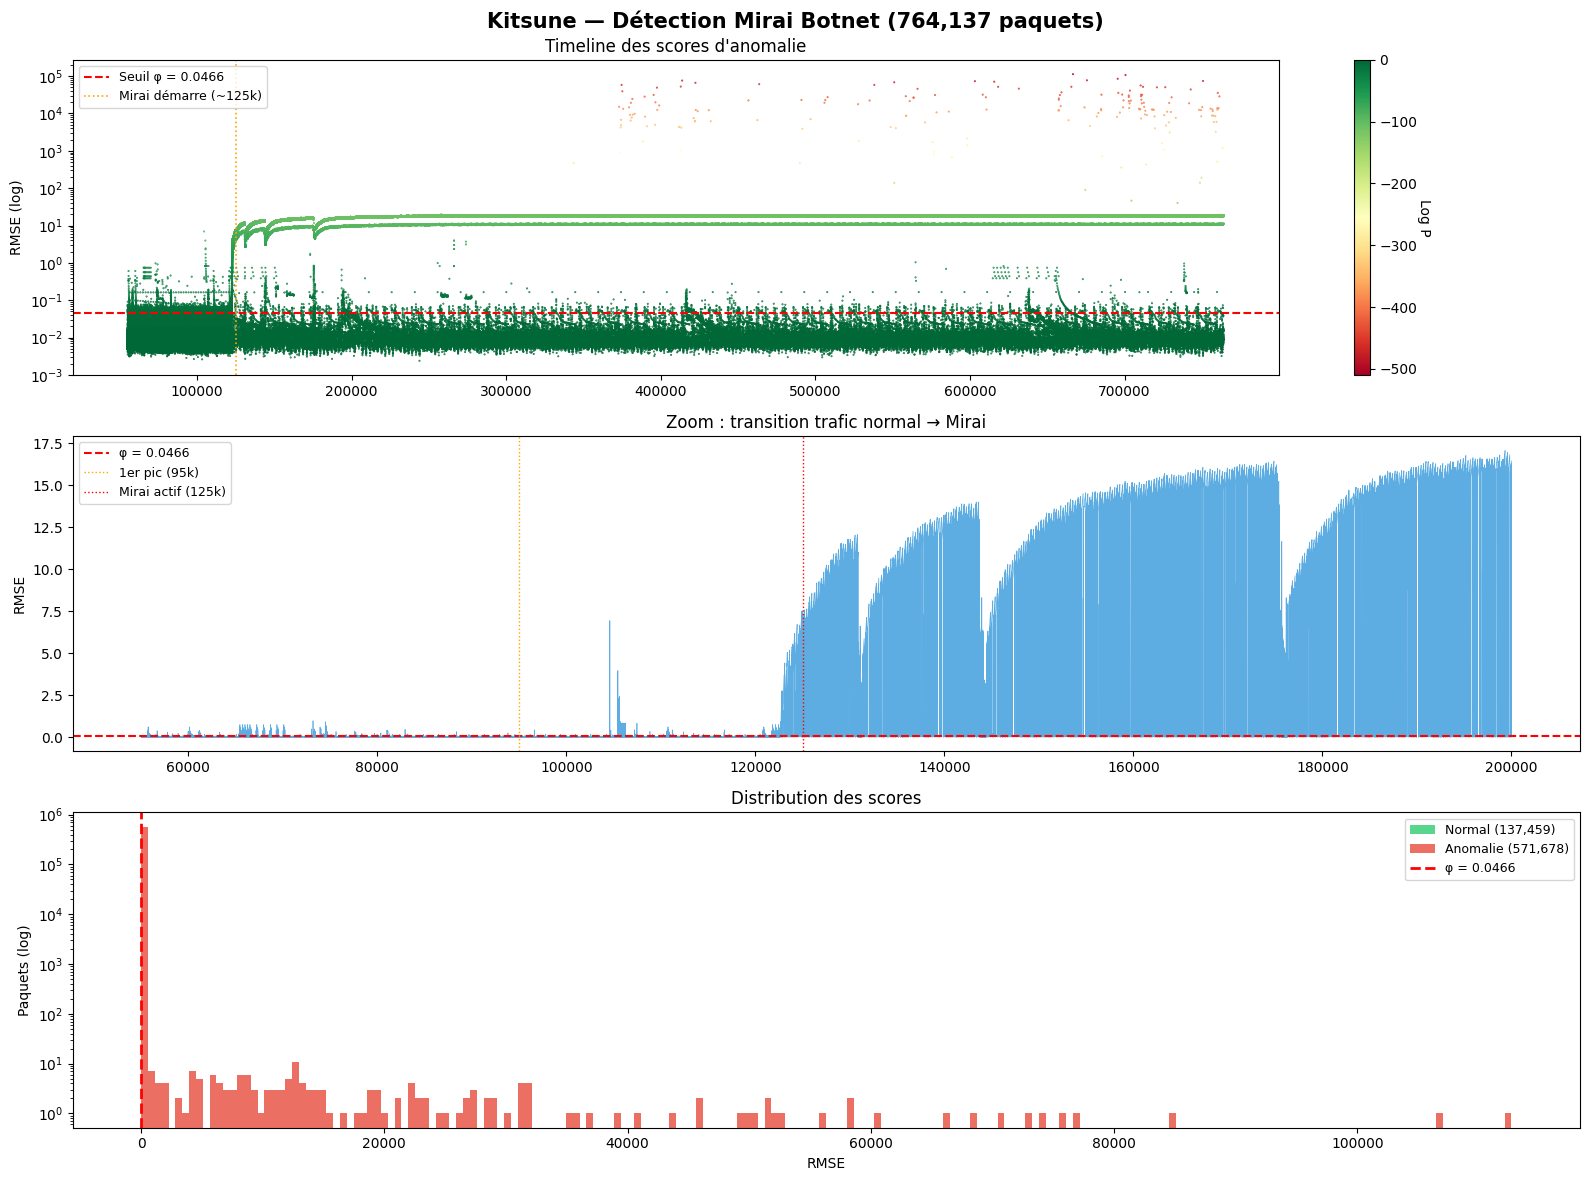

✅ Sauvegardé : kitsune_mirai_final.png


In [20]:
from scipy.stats import norm
from matplotlib import pyplot as plt
import numpy as np

FM_grace   = 5000
AD_grace   = 50000
exec_start = FM_grace + AD_grace

# ── Seuil φ ──────────────────────────────────────────────────────
RMSEs_exec   = np.array(RMSEs[exec_start:])
benign_exec  = RMSEs_exec[RMSEs_exec < 0.05]  # trafic normal uniquement
log_benign   = np.log(benign_exec + 1e-10)
mu, sigma    = np.mean(log_benign), np.std(log_benign)
phi          = np.exp(mu + 3 * sigma)

logProbs     = norm.logsf(np.log(RMSEs_exec + 1e-10), mu, sigma)

# ── Stats ─────────────────────────────────────────────────────────
anomalies = (RMSEs_exec > phi).sum()
normal    = (RMSEs_exec <= phi).sum()
taux      = anomalies / len(RMSEs_exec) * 100

print("=" * 50)
print(f"  Seuil φ              : {phi:.6f}")
print(f"  🔴 Anomalies         : {anomalies:,}  ({taux:.1f}%)")
print(f"  🟢 Normal            : {normal:,}  ({100-taux:.1f}%)")
print(f"  📦 Total exec        : {len(RMSEs_exec):,}")
print(f"  ⏱️  Durée             : 2689s (~45 min)")
print("=" * 50)

# ── Figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle("Kitsune — Détection Mirai Botnet (764,137 paquets)",
             fontsize=15, fontweight='bold')

x_range = np.arange(exec_start, exec_start + len(RMSEs_exec))

# Plot 1 : Timeline RMSE colorée
sc = axes[0].scatter(x_range, RMSEs_exec,
                     s=0.2, c=logProbs, cmap='RdYlGn')
axes[0].axhline(y=phi, color='red', linewidth=1.5,
                linestyle='--', label=f'Seuil φ = {phi:.4f}')
axes[0].axvline(x=125000, color='orange', linewidth=1.2,
                linestyle=':', label='Mirai démarre (~125k)')
axes[0].set_yscale('log')
axes[0].set_ylabel("RMSE (log)")
axes[0].set_title("Timeline des scores d'anomalie")
axes[0].legend(fontsize=9)
plt.colorbar(sc, ax=axes[0]).ax.set_ylabel('Log P', rotation=270, labelpad=10)

# Plot 2 : Zoom sur le début (transition normale → attaque)
zoom_end = 200000
x_zoom   = np.arange(exec_start, min(exec_start + zoom_end - exec_start,
                                      len(RMSEs_exec)) + exec_start)
r_zoom   = RMSEs_exec[:zoom_end - exec_start]
axes[1].plot(np.arange(exec_start, exec_start + len(r_zoom)),
             r_zoom, linewidth=0.5, color='#3498db', alpha=0.8)
axes[1].axhline(y=phi, color='red', linewidth=1.5,
                linestyle='--', label=f'φ = {phi:.4f}')
axes[1].axvline(x=95000,  color='orange', linewidth=1,
                linestyle=':', label='1er pic (95k)')
axes[1].axvline(x=125000, color='red',    linewidth=1,
                linestyle=':', label='Mirai actif (125k)')
axes[1].set_ylabel("RMSE")
axes[1].set_title("Zoom : transition trafic normal → Mirai")
axes[1].legend(fontsize=9)

# Plot 3 : Distribution
axes[2].hist(RMSEs_exec[RMSEs_exec <= phi],
             bins=200, color='#2ecc71', alpha=0.8, label=f'Normal ({normal:,})')
axes[2].hist(RMSEs_exec[RMSEs_exec > phi],
             bins=200, color='#e74c3c', alpha=0.8, label=f'Anomalie ({anomalies:,})')
axes[2].axvline(x=phi, color='red', linewidth=2,
                linestyle='--', label=f'φ = {phi:.4f}')
axes[2].set_xlabel("RMSE")
axes[2].set_ylabel("Paquets (log)")
axes[2].set_yscale('log')
axes[2].set_title("Distribution des scores")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig("kitsune_mirai_final.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : kitsune_mirai_final.png")